In [43]:
import os
import sys
import gc
import json
import pickle
from obspy import UTCDateTime, Stream
from obspy.geodetics import gps2dist_azimuth
from obspy.taup import taup_create
from matplotlib import pyplot as plt
from cartopy import crs as ccrs

import dask
from dask.distributed import Client as dask_Client
from dask.distributed import LocalCluster as dask_LocalCluster

path = '../code'
sys.path.insert(0, path)

import SeisScan as ss

# Creake DASK workers for parallel processing

In [2]:
# Create dask workers

os.cpu_count()

n_workers = os.cpu_count() - 2

dask_cluster = dask_LocalCluster()
dask_client = dask_Client(dask_cluster)
dask_cluster.scale(n_workers)

# Event information

In [3]:
evt0 = UTCDateTime('2016-07-11T05:55:16.388000')
evlo = -97.6889
evla = 36.617
evdp = 3.0
mag = 2.5

# Earth model

In [4]:
#--- database directory
model_name = 'okl'
model_file = f'{model_name}.tvel'

taup_create.build_taup_model(model_file, verbose=False)

# Travel time lookup table

In [5]:
file = 'tt_lookup_table.p'

tt_lookup_table = pickle.load(open(file, 'rb'))

mod_dist_r1 = tt_lookup_table['mod_dist_r1']
mod_dep_r1 = tt_lookup_table['mod_dep_r1']
mod_ttp_r2 = tt_lookup_table['mod_ttp_r2']
mod_tts_r2 = tt_lookup_table['mod_tts_r2']


# Subnetworks

In [6]:
#--- subnetworks file
rs_file = 'rs_list.json'

rs_list = json.load(open(rs_file, 'r'))

# Prepare station list

In [7]:
stations = []

for rs in rs_list:
    reference = rs['reference']
    secondaries = rs['secondaries']
    
    stations.append(reference)
    stations += secondaries
    

# Read data

In [8]:
db_dir = '../data'

starttime = evt0 - 10
endtime = starttime + 60

network = 'YW'
stationString = ','.join(stations)
location = ''
channel = 'DP?'

inv = ss.get_inv_from_db(db_dir, network, stationString, location, channel, starttime, endtime)
st_main = ss.read_sds(db_dir, network, stationString, location, channel, starttime, endtime)

# Pre-process

In [44]:
gc.collect()

#--- take a copy of the waveform
st = st_main.copy()

#--- detrend the data
st.detrend(type='linear')

#--- remove instrument response
pre_filt = [0.1, 0.2, 200.0, 250.0]   # Hz
st.remove_response(output='VEL', pre_filt=pre_filt);

#--- rotation from 'Z12' to 'ZNE
st.rotate('->ZNE', inventory=inv);

#--- filter
f1, f2 = 25.0, 75.0
st.select(component='Z').filter('bandpass', freqmin=f1, freqmax=f2);

f1, f2 = 10.0, 30.0
st.select(component='N').filter('bandpass', freqmin=f1, freqmax=f2);
st.select(component='E').filter('bandpass', freqmin=f1, freqmax=f2);

2024-06-24 12:12:35,455 - distributed.utils_perf - WARNING - full garbage collections took 20% CPU time recently (threshold: 10%)


# Compute local similarity

In [45]:
gc.collect()

components = ['Z', 'N', 'E']
w = 0.75 # window length in seconds
dt = 0.05 # stride in seconds
max_lag = 0.1 # maximum lag in seconds

st_r = Stream()
st_s = Stream()
st_pcc = Stream()
st_dpcc = Stream()
st_ls = Stream()
st_dls = Stream()

for component in components:

    st_r_, st_s_, st_pcc_, st_dpcc_, st_ls_, st_dls_ = ss.do_ls(st, component, rs_list=rs_list, max_lag=max_lag)

    st_r += st_r_
    st_s += st_s_
    st_pcc += st_pcc_
    st_dpcc += st_dpcc_
    st_ls += st_ls_
    st_dls += st_dls_

2024-06-24 12:12:42,593 - distributed.utils_perf - WARNING - full garbage collections took 20% CPU time recently (threshold: 10%)


# Do backprojection

In [46]:
gc.collect()

#--- prepare source grid
min_lon, max_lon = -97.75, -97.59        # deg
min_lat, max_lat = 36.59, 36.64          # deg
min_dep, max_dep = 0, 15                 # km
step_x, step_y, step_z = 0.25, 0.25, 0.25  # km

#--- calculation of time window
w = 0.25 # window size in seconds
o = 0.80 # overlap fraction

pos = 'mid'

#--- components for calculation
p_components = ['Z']
s_components = ['N', 'E']

# p_components = ['Z', 'N', 'E']
# s_components = ['Z', 'N', 'E']

brightness4 = ss.do_bp(st_dls, dask_client, w,
            min_lon, max_lon, min_lat, max_lat, min_dep, max_dep, step_x, step_y, step_z,
            mod_dist_r1, mod_dep_r1, mod_ttp_r2, mod_tts_r2,
            o=o,
            pos=pos,
            p_components=p_components,
            s_components=s_components)

2024-06-24 12:12:51,203 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)
2024-06-24 12:12:51,399 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)
2024-06-24 12:12:51,562 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)
2024-06-24 12:12:51,716 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)
2024-06-24 12:12:51,882 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)
2024-06-24 12:12:52,031 - distributed.utils_perf - WARNING - full garbage collections took 18% CPU time recently (threshold: 10%)
2024-06-24 12:12:52,181 - distributed.utils_perf - WARNING - full garbage collections took 18% CPU time recently (threshold: 10%)
2024-06-24 12:12:54,731 - distributed.utils_perf - WARNING - full garbage collections took

# Get backprojected solution

In [47]:
evt0_bp, evlo_bp, evla_bp, evdp_bp = brightness4.get_solution()

# Backprojected solution
print(f'Backprojected event origin time: {evt0_bp.strftime("%Y-%m-%d %H:%M:%S.%f")}')
print(f'Backprojected event longitude: {evlo_bp:0.04f} deg.')
print(f'Backprojected event latitude: {evla_bp:0.04f} deg.')
print(f'Backprojected event depth: {evdp_bp:0.02f} km.')

print()

# Difference between backprojected and analyst origin time
evt0_diff = evt0_bp - evt0

# Distance between backprojected and analyst epicenter
dist_meter, _, _ = gps2dist_azimuth(evla, evlo, evla_bp, evlo_bp)
dist_km = dist_meter / 1000

# Difference between backprojected and analyst depth
depth_diff = evdp_bp - evdp

print(f'Difference between backprojected and analyst origin time: {evt0_diff:0.02f} seconds.')
print(f'Distance between backprojected and analyst epicenter: {dist_km:0.02f} km.')
print(f'Difference between backprojected and analyst depth: {depth_diff:0.02f} km.')

Backprojected event origin time: 2016-07-11 05:55:16.588000
Backprojected event longitude: -97.6885 deg.
Backprojected event latitude: 36.6148 deg.
Backprojected event depth: 2.75 km.

Difference between backprojected and analyst origin time: 0.20 seconds.
Distance between backprojected and analyst epicenter: 0.25 km.
Difference between backprojected and analyst depth: -0.25 km.


# Plot brightness

In [48]:
#--- get station lat, long
stlo = [st.select(station=station)[0].stats.sac.stlo for station in stations]
stla = [st.select(station=station)[0].stats.sac.stla for station in stations]

#### Plot XY slice

2024-06-24 12:13:33,360 - distributed.utils_perf - WARNING - full garbage collections took 18% CPU time recently (threshold: 10%)


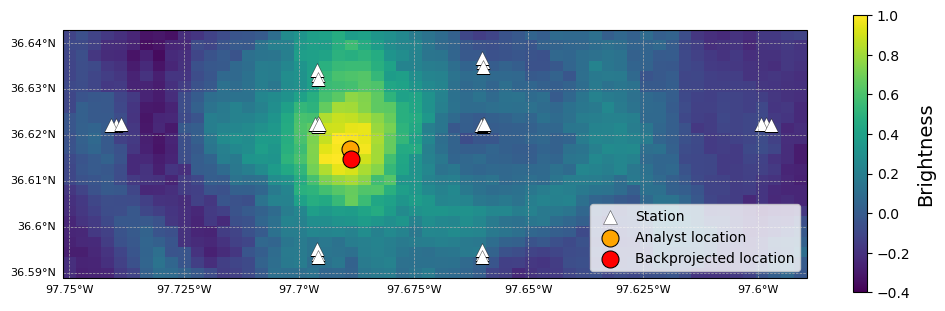

In [49]:
gc.collect()

plt.close('all')
fig = plt.figure(figsize=(12,12))
projection = ccrs.PlateCarree()
ax = fig.add_subplot(projection=projection)

#--- axes gridlines and ticklabels
gl = ax.gridlines(ls='--', lw=0.5)
gl.bottom_labels = True
gl.left_labels = True
gl.xlabel_style = {'fontsize':8}
gl.ylabel_style = {'fontsize':8}

#--- Plot brightness
s = brightness4.plot_slice(ax, plane='xy', t=evt0_bp)
s.set_clim(vmin=-0.4, vmax=1.0)

cbar = fig.colorbar(s, shrink=0.3);
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_ylabel('Brightness', fontsize=14)

#--- plot stations
ax.scatter(stlo, stla, marker='^', ec='k', fc='w', lw=0.25, s=100, label='Station')

#--- plot analyst event
ax.scatter(evlo, evla, marker='o', ec='k', fc='orange', lw=0.75, s=150, label='Analyst location')

#--- plot backprojected event
ax.scatter(evlo_bp, evla_bp, marker='o', ec='k', fc='red', lw=0.75, s=150, label='Backprojected location')

#--- legend
ax.legend(loc=4);

#### YZ slice

2024-06-24 12:13:43,052 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)


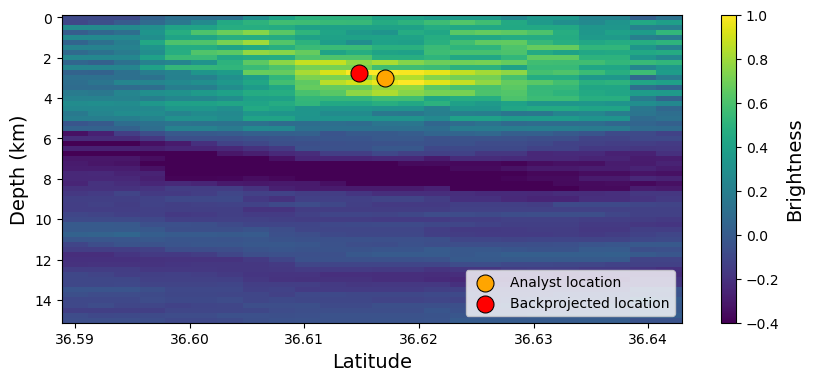

In [50]:
gc.collect()

plt.close('all')
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1,1,1)
ax.invert_yaxis()

ax.set_xlabel('Latitude', fontsize=14)
ax.set_ylabel('Depth (km)', fontsize=14);

#--- Plot brightness
s = brightness4.plot_slice(ax, plane='yz', t=evt0_bp)
s.set_clim(vmin=-0.4, vmax=1.0)

cbar = fig.colorbar(s, shrink=1.0);
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_ylabel('Brightness', fontsize=14)

#--- plot analyst event
ax.scatter(evla, evdp, marker='o', ec='k', fc='orange', lw=0.75, s=150, label='Analyst location')

#--- plot backprojected event
ax.scatter(evla_bp, evdp_bp, marker='o', ec='k', fc='red', lw=0.75, s=150, label='Backprojected location')

#--- legend
ax.legend(loc=4);

#### ZX slice

2024-06-24 12:13:46,899 - distributed.utils_perf - WARNING - full garbage collections took 18% CPU time recently (threshold: 10%)


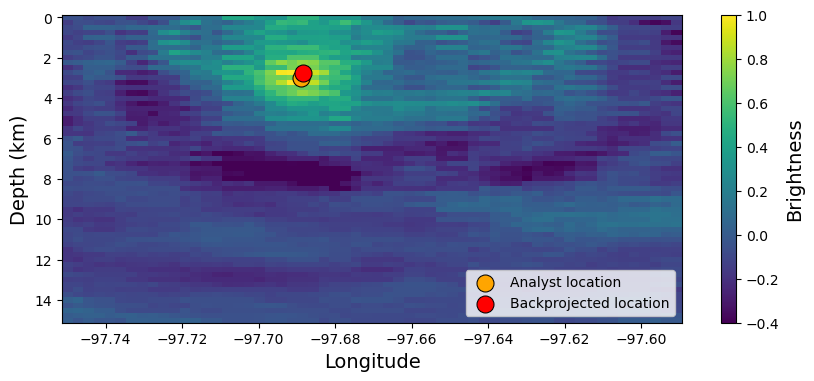

In [51]:
gc.collect()

plt.close('all')
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1,1,1)
ax.invert_yaxis()

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Depth (km)', fontsize=14);

#--- Plot brightness
s = brightness4.plot_slice(ax, plane='zx', t=evt0_bp)
s.set_clim(vmin=-0.4, vmax=1.0)

cbar = fig.colorbar(s, shrink=1.0);
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_ylabel('Brightness', fontsize=14)

# #--- plot analyst event
ax.scatter(evlo, evdp, marker='o', ec='k', fc='orange', lw=0.75, s=150, label='Analyst location')

# #--- plot backprojected event
ax.scatter(evlo_bp, evdp_bp, marker='o', ec='k', fc='red', lw=0.75, s=150, label='Backprojected location')

# #--- legend
ax.legend(loc=4);

# Plot record section of the reference waveforms and backprojected stack

In [52]:
brightness_stack = brightness4.get_stack()
times = brightness_stack.get_times(reftime=evt0_bp)      # time of the stack
b_r1 = brightness_stack.b_r1                             # brightness of the stack

2024-06-24 12:16:06,755 - distributed.utils_perf - WARNING - full garbage collections took 14% CPU time recently (threshold: 10%)


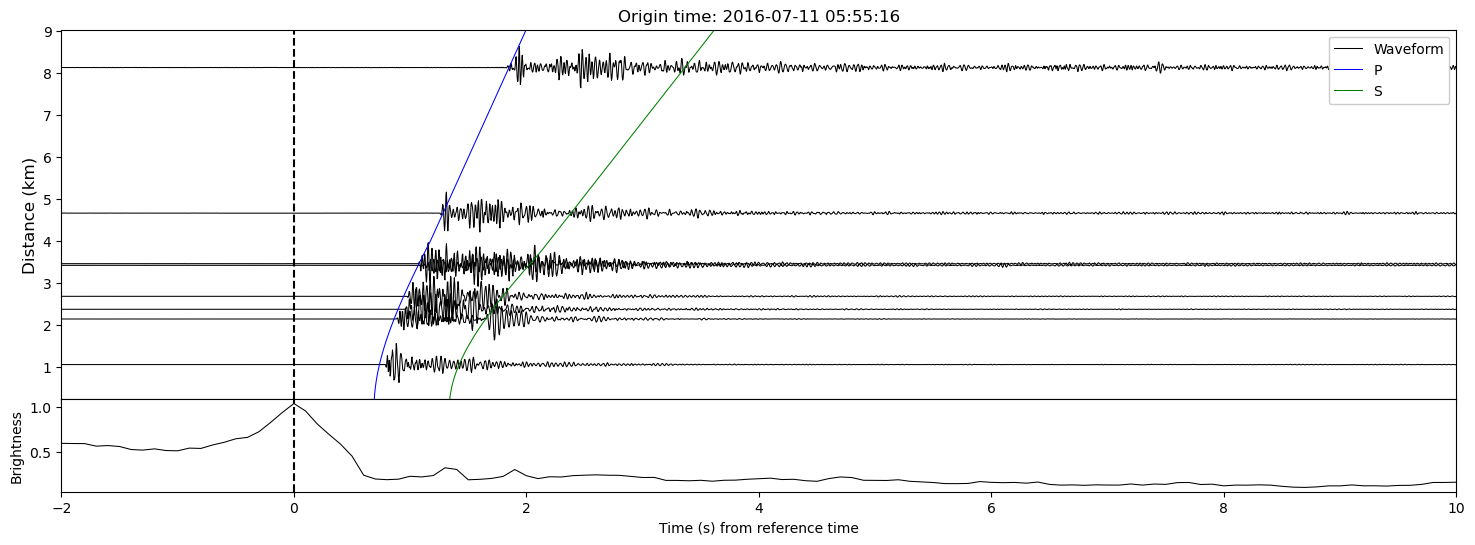

In [57]:
gc.collect()

#--- Channel codes for this example are DPZ, DPN, DPE
channel = 'DPZ'

plt.close('all')

%matplotlib inline

#--- create figure and axes
fig = plt.figure(figsize=(18,6))
gs = fig.add_gridspec(5, hspace=0.0)
ax = fig.add_subplot(gs[0:4,0])
ax2 = fig.add_subplot(gs[4,0], sharex=ax)

ax2.set_ylabel('Brightness')
ax2.set_xlabel('Time (s) from reference time')

#--- remove xticklabels from ax
[label.set_visible(False) for label in ax.get_xticklabels()]

#--- plot record section of the reference waveforms
ss.prs(st_r.select(channel=channel), evt0_bp, evlo_bp, evla_bp, evdp_bp, ax=ax, model_name=model_name, xmin=-2, xmax=10)
ax.axvline(0, color='k', ls='--')

# #--- plot stack
ax2.plot(times, b_r1, color='k', lw=0.75)
ax2.axvline(0, color='k', ls='--');

# Close all DASK workers

In [32]:
#--- close dask client
dask_client.close()
dask_cluster.close()